In [ ]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

In [2]:
train_df = pd.read_csv("../data/processed/train_processed.csv")
test_df = pd.read_csv("../data/processed/test_processed.csv")

print("Training shape:", train_df.shape)
print("Testing shape:", test_df.shape)

Training shape: (10003, 3)
Testing shape: (3080, 3)


In [3]:
X_text_train = train_df["clean_text"]
X_text_test = test_df["clean_text"]

y_train = train_df["category"]
y_test = test_df["category"]

In [4]:
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training labels: (10003,)
Testing labels: (3080,)


In [6]:
tfidf = TfidfVectorizer(
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

In [7]:
X_train = tfidf.fit_transform(X_text_train)
X_test = tfidf.transform(X_text_test)

In [8]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)

X_train: (10003, 10292)
X_test: (3080, 10292)


In [10]:
print("Number of classes:", y_train.nunique())

Number of classes: 77


In [11]:
print(y_train.value_counts().head(10))

category
card_payment_fee_charged                            187
direct_debit_payment_not_recognised                 182
balance_not_updated_after_cheque_or_cash_deposit    181
wrong_amount_of_cash_received                       180
cash_withdrawal_charge                              177
transaction_charged_twice                           175
declined_cash_withdrawal                            173
transfer_fee_charged                                172
transfer_not_received_by_recipient                  171
balance_not_updated_after_bank_transfer             171
Name: count, dtype: int64


In [13]:
lr_model = LogisticRegression(
    max_iter=1000
)

In [14]:
lr_model.fit(X_train, y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use i

In [15]:
y_pred_lr = lr_model.predict(X_test)

In [16]:
for actual, predicted in zip(y_test.iloc[:10], y_pred_lr[:10]):
    print(f"Actual: {actual}")
    print(f"Predicted: {predicted}")
    print("-" * 50)

Actual: card_arrival
Predicted: card_linking
--------------------------------------------------
Actual: card_arrival
Predicted: card_arrival
--------------------------------------------------
Actual: card_arrival
Predicted: transfer_not_received_by_recipient
--------------------------------------------------
Actual: card_arrival
Predicted: card_arrival
--------------------------------------------------
Actual: card_arrival
Predicted: card_arrival
--------------------------------------------------
Actual: card_arrival
Predicted: card_delivery_estimate
--------------------------------------------------
Actual: card_arrival
Predicted: card_arrival
--------------------------------------------------
Actual: card_arrival
Predicted: card_arrival
--------------------------------------------------
Actual: card_arrival
Predicted: card_arrival
--------------------------------------------------
Actual: card_arrival
Predicted: card_arrival
--------------------------------------------------


In [18]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)

lr_precision = precision_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

lr_recall = recall_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

lr_f1 = f1_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

In [19]:
print("Logistic Regression Results")
print("-" * 35)

print(f"Accuracy:  {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall:    {lr_recall:.4f}")
print(f"F1 Score:  {lr_f1:.4f}")

Logistic Regression Results
-----------------------------------
Accuracy:  0.8578
Precision: 0.8672
Recall:    0.8578
F1 Score:  0.8568


In [20]:
print(
    classification_report(
        y_test,
        y_pred_lr,
        digits=4
    )
)

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up     0.8837    0.9500    0.9157        40
                                activate_my_card     1.0000    0.9500    0.9744        40
                                       age_limit     1.0000    1.0000    1.0000        40
                         apple_pay_or_google_pay     0.9756    1.0000    0.9877        40
                                     atm_support     0.8649    0.8000    0.8312        40
                                automatic_top_up     1.0000    0.9000    0.9474        40
         balance_not_updated_after_bank_transfer     0.6458    0.7750    0.7045        40
balance_not_updated_after_cheque_or_cash_deposit     0.8409    0.9250    0.8810        40
                         beneficiary_not_allowed     0.8974    0.8750    0.8861        40
                                 cancel_transfer     0.8837    0.9500    0.9157        40
         

In [22]:
svm_model = LinearSVC()

In [23]:
svm_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [24]:
y_pred_svm = svm_model.predict(X_test)

In [25]:
svm_accuracy = accuracy_score(y_test, y_pred_svm)

svm_precision = precision_score(
    y_test,
    y_pred_svm,
    average="weighted"
)

svm_recall = recall_score(
    y_test,
    y_pred_svm,
    average="weighted"
)

svm_f1 = f1_score(
    y_test,
    y_pred_svm,
    average="weighted"
)

In [26]:
print("Linear SVM Results")
print("-" * 35)

print(f"Accuracy:  {svm_accuracy:.4f}")
print(f"Precision: {svm_precision:.4f}")
print(f"Recall:    {svm_recall:.4f}")
print(f"F1 Score:  {svm_f1:.4f}")

Linear SVM Results
-----------------------------------
Accuracy:  0.8893
Precision: 0.8930
Recall:    0.8893
F1 Score:  0.8893


In [27]:
print(
    classification_report(
        y_test,
        y_pred_svm,
        digits=4
    )
)

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up     0.9500    0.9500    0.9500        40
                                activate_my_card     0.9744    0.9500    0.9620        40
                                       age_limit     0.9524    1.0000    0.9756        40
                         apple_pay_or_google_pay     1.0000    1.0000    1.0000        40
                                     atm_support     0.9000    0.9000    0.9000        40
                                automatic_top_up     1.0000    0.9500    0.9744        40
         balance_not_updated_after_bank_transfer     0.6667    0.7500    0.7059        40
balance_not_updated_after_cheque_or_cash_deposit     0.9024    0.9250    0.9136        40
                         beneficiary_not_allowed     0.9268    0.9500    0.9383        40
                                 cancel_transfer     0.9268    0.9500    0.9383        40
         

In [29]:
nb_model = MultinomialNB()

In [30]:
nb_model.fit(X_train, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](77,)","[162.,159.,110.,...,121.,180.,163.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](77,)","[-4.12,-4.14,-4.51,...,-4.41,-4.02,-4.12]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[<U48](77,)","['Refund_not_showing_up','activate_my_card','age_limit',..., 'why_verify_identity','wrong_amount_of_cash_received', 'wrong_exchange_rate_for_cash_withdrawal']"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](77, 10292)","[[0. ,0. ,0. ,...,0. ,0. ,0. ], [0. ,0. ,0. ,...,0. ,0. ,0. ], [0. ,0. ,0. ,...,0. ,0. ,0. ], ..., [0. ,0. ,0. ,...,0. ,0. ,0. ], [0.62,0.26,0. ,...,0. ,0. ,0. ], [0. ,0. ,0. ,...,0. ,0.17,0.18]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](77, 10292)","[[-9.3 ,-9.3 ,-9.3 ,...,-9.3 ,-9.3 ,-9.3 ], [-9.29,-9.29,-9.29,...,-9.29,-9.29,-9.29], [-9.28,-9.28,-9.28,...,-9.28,-9.28,-9.28], ..., [-9.28,-9.28,-9.28,...,-9.28,-9.28,-9.28], [-8.83,-9.08,-9.31,...,-9.31,-9.31,-9.31], [-9.31,-9.31,-9.31,...,-9.31,-9.15,-9.14]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,10292


In [31]:
y_pred_nb = nb_model.predict(X_test)

In [32]:
nb_accuracy = accuracy_score(y_test, y_pred_nb)

nb_precision = precision_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

nb_recall = recall_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

nb_f1 = f1_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

In [33]:
print("Naive Bayes Results")
print("-" * 35)

print(f"Accuracy:  {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall:    {nb_recall:.4f}")
print(f"F1 Score:  {nb_f1:.4f}")

Naive Bayes Results
-----------------------------------
Accuracy:  0.7990
Precision: 0.8329
Recall:    0.7990
F1 Score:  0.7857


In [34]:
print(
    classification_report(
        y_test,
        y_pred_nb,
        digits=4
    )
)

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up     0.8537    0.8750    0.8642        40
                                activate_my_card     0.5758    0.9500    0.7170        40
                                       age_limit     1.0000    1.0000    1.0000        40
                         apple_pay_or_google_pay     0.8163    1.0000    0.8989        40
                                     atm_support     0.8276    0.6000    0.6957        40
                                automatic_top_up     0.9474    0.9000    0.9231        40
         balance_not_updated_after_bank_transfer     0.6429    0.6750    0.6585        40
balance_not_updated_after_cheque_or_cash_deposit     0.6129    0.9500    0.7451        40
                         beneficiary_not_allowed     0.7708    0.9250    0.8409        40
                                 cancel_transfer     0.8864    0.9750    0.9286        40
         

In [36]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [37]:
rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total

In [38]:
y_pred_rf = rf_model.predict(X_test)

In [39]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

rf_precision = precision_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

rf_recall = recall_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

rf_f1 = f1_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

In [40]:
print("Random Forest Results")
print("-" * 35)

print(f"Accuracy:  {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall:    {rf_recall:.4f}")
print(f"F1 Score:  {rf_f1:.4f}")

Random Forest Results
-----------------------------------
Accuracy:  0.8581
Precision: 0.8653
Recall:    0.8581
F1 Score:  0.8581


In [41]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        digits=4
    )
)

                                                  precision    recall  f1-score   support

                           Refund_not_showing_up     0.8810    0.9250    0.9024        40
                                activate_my_card     0.9211    0.8750    0.8974        40
                                       age_limit     1.0000    1.0000    1.0000        40
                         apple_pay_or_google_pay     1.0000    1.0000    1.0000        40
                                     atm_support     0.8947    0.8500    0.8718        40
                                automatic_top_up     0.9474    0.9000    0.9231        40
         balance_not_updated_after_bank_transfer     0.7436    0.7250    0.7342        40
balance_not_updated_after_cheque_or_cash_deposit     0.8333    0.8750    0.8537        40
                         beneficiary_not_allowed     1.0000    0.7750    0.8732        40
                                 cancel_transfer     0.9512    0.9750    0.9630        40
         

In [43]:
cm = confusion_matrix(
    y_test,
    y_pred_svm,
    labels=svm_model.classes_
)

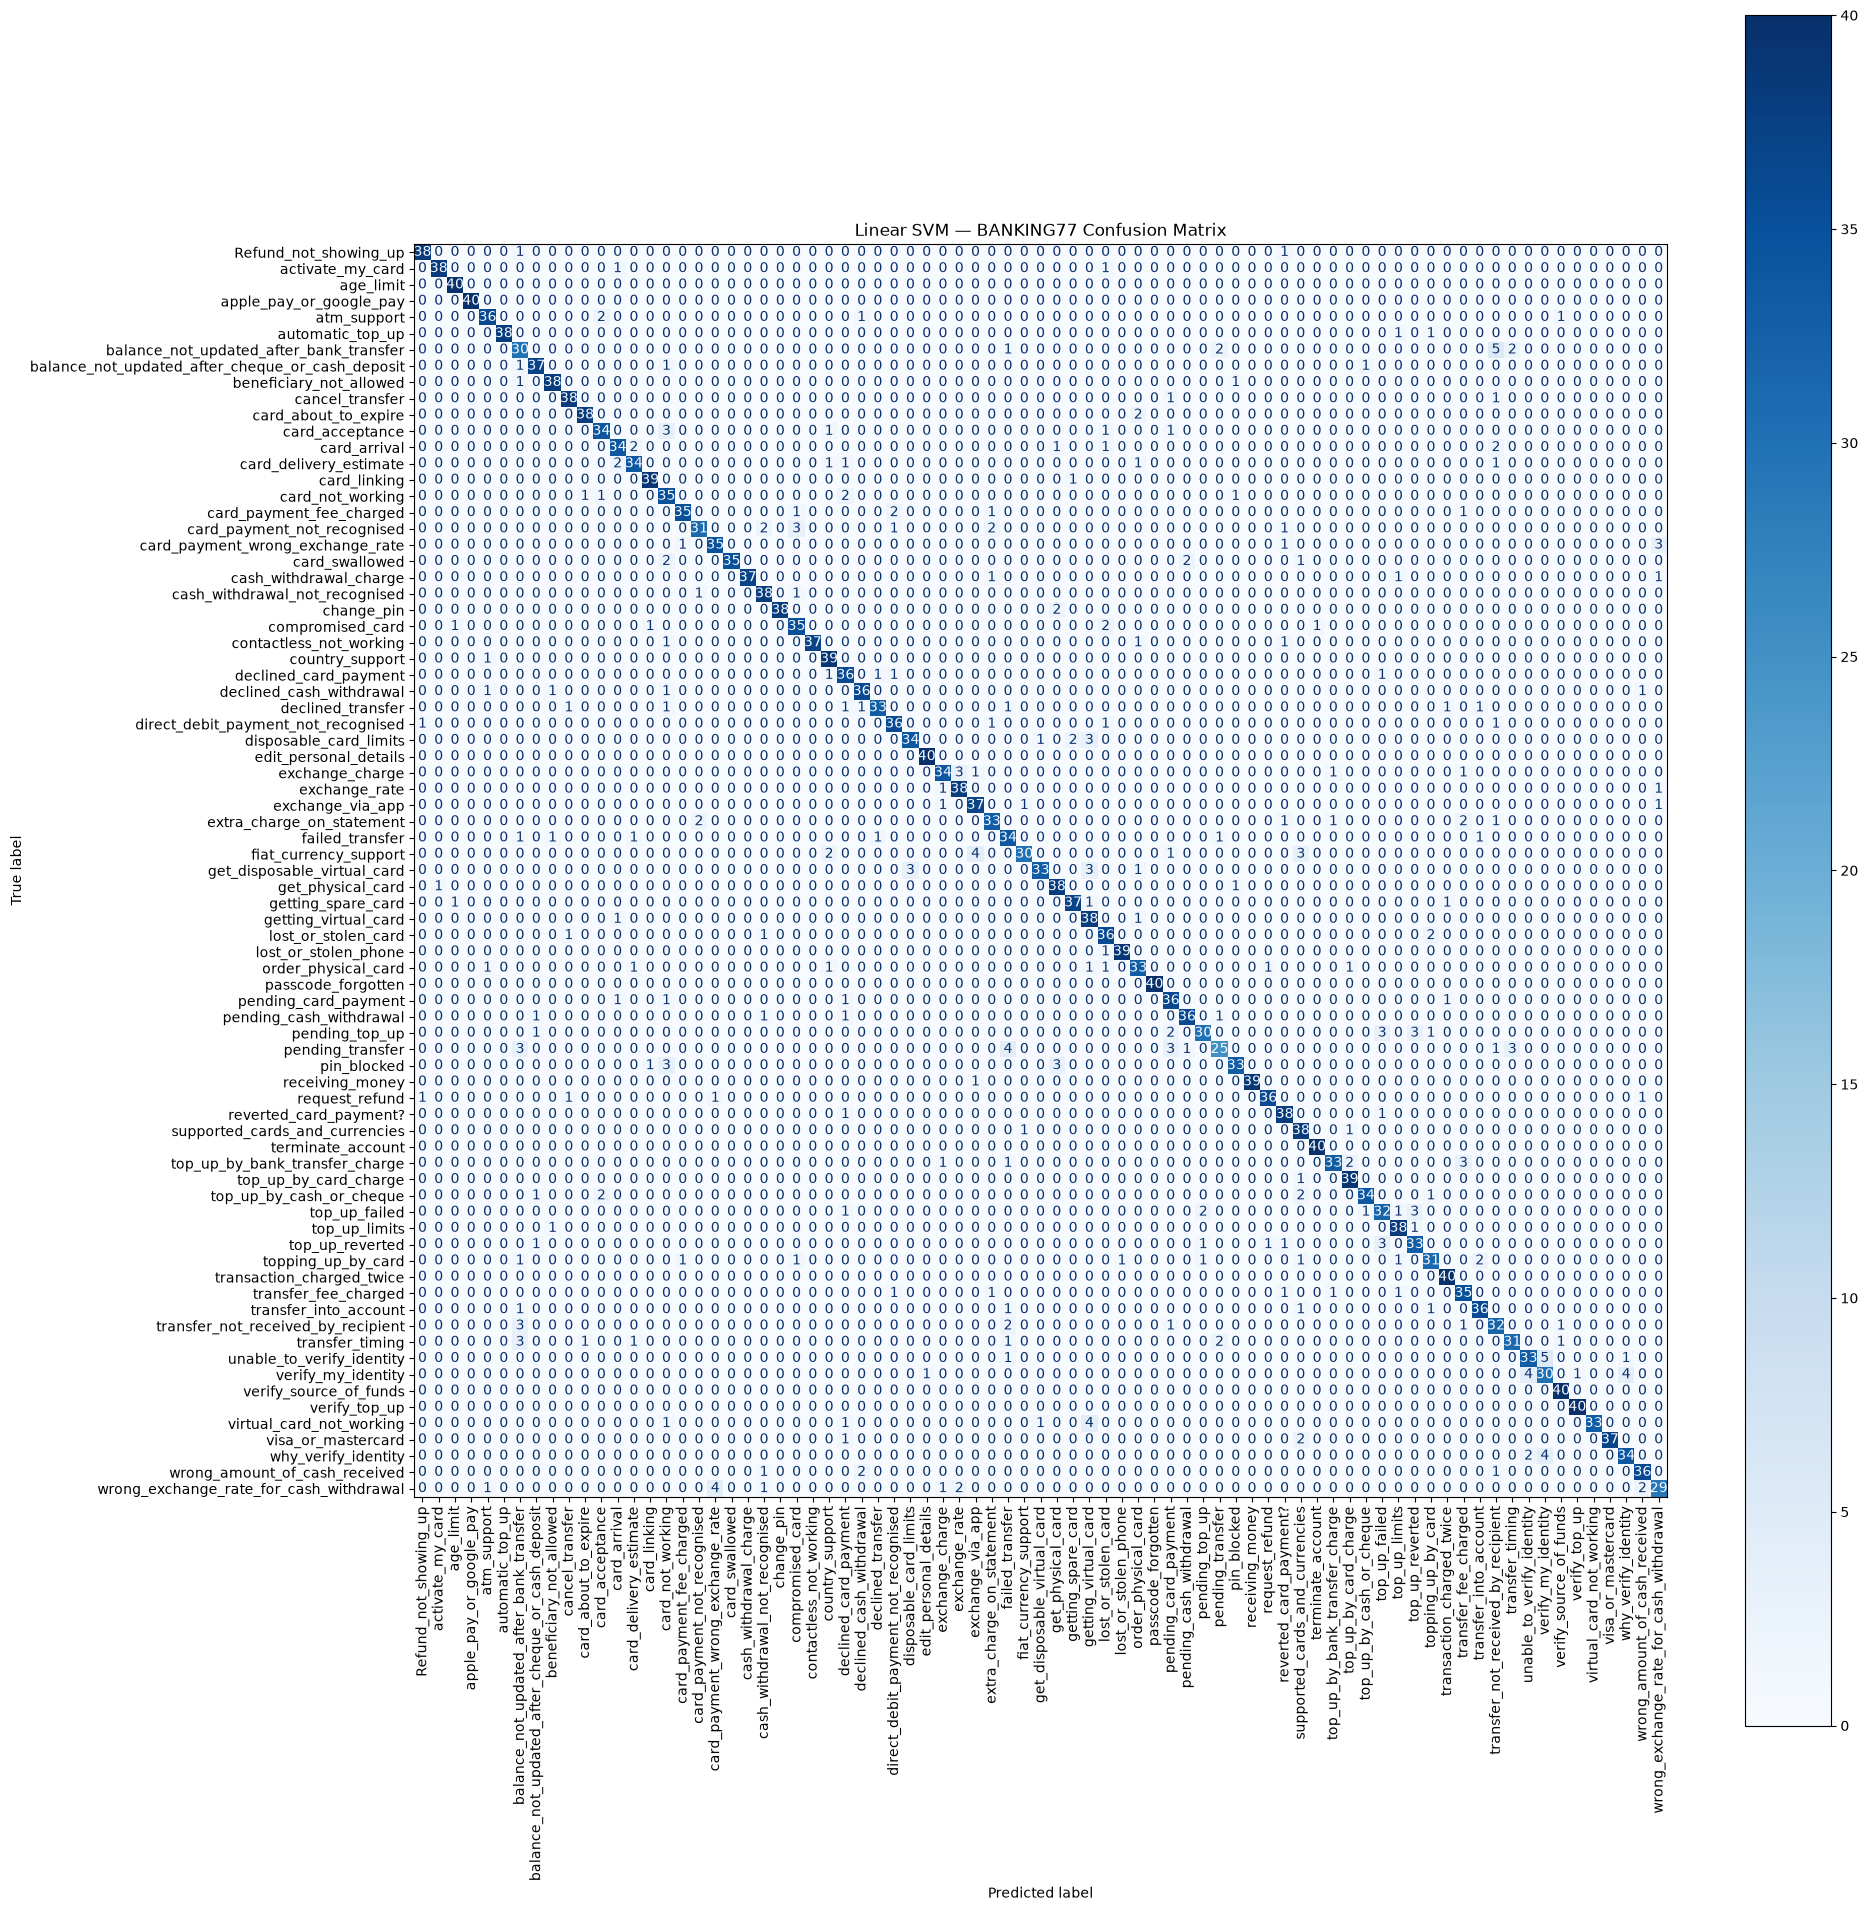

In [44]:
fig, ax = plt.subplots(figsize=(20, 20))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=svm_model.classes_
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    cmap="Blues"
)

plt.title("Linear SVM — BANKING77 Confusion Matrix")
plt.tight_layout()
plt.show()

In [45]:
cm_no_diag = cm.copy()

np.fill_diagonal(cm_no_diag, 0)

confusion_pairs = []

for i in range(len(svm_model.classes_)):
    for j in range(len(svm_model.classes_)):
        if cm_no_diag[i, j] > 0:
            confusion_pairs.append(
                (
                    cm_no_diag[i, j],
                    svm_model.classes_[i],
                    svm_model.classes_[j]
                )
            )

confusion_pairs = sorted(
    confusion_pairs,
    reverse=True
)

for count, actual, predicted in confusion_pairs[:15]:
    print(
        f"Actual: {actual} → "
        f"Predicted: {predicted} | "
        f"Count: {count}"
    )

Actual: unable_to_verify_identity → Predicted: verify_my_identity | Count: 5
Actual: balance_not_updated_after_bank_transfer → Predicted: transfer_not_received_by_recipient | Count: 5
Actual: wrong_exchange_rate_for_cash_withdrawal → Predicted: card_payment_wrong_exchange_rate | Count: 4
Actual: why_verify_identity → Predicted: verify_my_identity | Count: 4
Actual: virtual_card_not_working → Predicted: getting_virtual_card | Count: 4
Actual: verify_my_identity → Predicted: why_verify_identity | Count: 4
Actual: verify_my_identity → Predicted: unable_to_verify_identity | Count: 4
Actual: pending_transfer → Predicted: failed_transfer | Count: 4
Actual: fiat_currency_support → Predicted: exchange_via_app | Count: 4
Actual: transfer_timing → Predicted: balance_not_updated_after_bank_transfer | Count: 3
Actual: transfer_not_received_by_recipient → Predicted: balance_not_updated_after_bank_transfer | Count: 3
Actual: top_up_reverted → Predicted: top_up_failed | Count: 3
Actual: top_up_failed

In [47]:
scores = svm_model.decision_function(X_test)

print("Number of test samples:", scores.shape[0])
print("Number of classes:", scores.shape[1])

Number of test samples: 3080
Number of classes: 77


In [48]:
sample_index = 0

sample_scores = scores[sample_index]

top_indices = np.argsort(sample_scores)[-5:][::-1]

for idx in top_indices:
    print(
        svm_model.classes_[idx],
        "→",
        sample_scores[idx]
    )

get_physical_card → -0.18900516020884517
activate_my_card → -0.7612276712582381
card_linking → -0.7977019794174875
card_not_working → -0.8905622545866924
card_swallowed → -0.9038687946877016


In [49]:
top_scores = scores.max(axis=1)

In [50]:
print(top_scores[:20])

[-0.18900516  1.12753621 -0.2486681   0.01844308 -0.10935968  0.3538779
  1.00137959  0.17376786 -0.37508307 -0.13491368  0.29198431  0.06816468
  0.23651167  0.65998055  0.35402118 -0.2851377  -0.26575906  0.31199159
  1.00197499  0.60495732]


In [51]:
sorted_scores = np.sort(scores, axis=1)

top_score = sorted_scores[:, -1]
second_score = sorted_scores[:, -2]

margin = top_score - second_score

In [52]:
print("First 20 margins:")
print(margin[:20])

First 20 margins:
[0.57222251 1.69770271 0.20909116 0.46647341 0.05313505 0.74724747
 1.79960071 0.84054083 0.44398755 0.66285992 0.89621011 0.60125179
 0.71025111 1.35201903 1.22518352 0.46563257 0.46742859 1.07524118
 1.46731578 1.39908971]


In [53]:
print("Minimum margin:", margin.min())
print("Maximum margin:", margin.max())
print("Mean margin:", margin.mean())

Minimum margin: 0.00023897532950434286
Maximum margin: 3.5248510334204743
Mean margin: 1.158944459151008


In [54]:
predictions = svm_model.predict(X_test)

correct = predictions == y_test.to_numpy()

In [55]:
print("Correct predictions:", correct.sum())
print("Incorrect predictions:", (~correct).sum())

Correct predictions: 2739
Incorrect predictions: 341


In [56]:
print(
    "Average margin for correct predictions:",
    margin[correct].mean()
)

print(
    "Average margin for incorrect predictions:",
    margin[~correct].mean()
)

Average margin for correct predictions: 1.2657463016466561
Average margin for incorrect predictions: 0.3010844984601577


In [58]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 1.0, 1.2]

for threshold in thresholds:
    accepted = margin >= threshold

    coverage = accepted.mean()
    accuracy = correct[accepted].mean() if accepted.sum() > 0 else 0

    print(
        f"Threshold: {threshold:.1f} | "
        f"Coverage: {coverage:.2%} | "
        f"Accuracy: {accuracy:.2%} | "
        f"Accepted: {accepted.sum()}"
    )

Threshold: 0.1 | Coverage: 95.16% | Accuracy: 91.95% | Accepted: 2931
Threshold: 0.2 | Coverage: 91.14% | Accuracy: 93.69% | Accepted: 2807
Threshold: 0.3 | Coverage: 87.08% | Accuracy: 95.38% | Accepted: 2682
Threshold: 0.4 | Coverage: 83.64% | Accuracy: 96.20% | Accepted: 2576
Threshold: 0.5 | Coverage: 79.35% | Accuracy: 97.14% | Accepted: 2444
Threshold: 0.6 | Coverage: 75.62% | Accuracy: 97.98% | Accepted: 2329
Threshold: 0.7 | Coverage: 71.82% | Accuracy: 98.42% | Accepted: 2212
Threshold: 0.8 | Coverage: 67.44% | Accuracy: 98.94% | Accepted: 2077
Threshold: 1.0 | Coverage: 58.44% | Accuracy: 99.44% | Accepted: 1800
Threshold: 1.2 | Coverage: 47.99% | Accuracy: 99.53% | Accepted: 1478


In [ ]:
os.makedirs("../models", exist_ok=True)

joblib.dump(svm_model, "../models/svm_model.pkl")
joblib.dump(tfidf, "../models/tfidf_vectorizer.pkl")

print("SVM model saved.")
print("TF-IDF vectorizer saved.")
print(os.path.exists("../models/svm_model.pkl"))
print(os.path.exists("../models/tfidf_vectorizer.pkl"))